<h2>Problema de classificação desbalanceada</h2>
<p>Fraudes são raras --> modelos podem ignorar a classe 1</p> 

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [28]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [29]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [30]:
df["Amount_log"] = np.log1p(df["Amount"])

In [31]:
from sklearn.preprocessing import StandardScaler
#vai deixar valores grandes e pequenos comparaveis

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [32]:
#Preparando os dados para treinar o modelo

from sklearn.model_selection import train_test_split

x = df.drop("Class", axis = 1) #características
y = df["Class"] #o que queremos ver

x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, random_state=42, test_size=0.3
)

<h2>Regressão Logística</h2>
<p>Vamos utilizar o modelo de Regressão Logística, é um modelo estatístico matemático de classficação, nesse caso ele vai dizer se é uma fraude ou não</p>

In [33]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=2000)

modelo.fit(x_train, y_train)

y_pred = modelo.predict(x_test)

c:\Users\Cd434\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.88      0.68      0.76       148

    accuracy                           1.00     85443
   macro avg       0.94      0.84      0.88     85443
weighted avg       1.00      1.00      1.00     85443



-A accuracy pode ser alta mesmo sem detectar fraude, por isso deve-se prestar atenção nas outras métricas
-O modelo mostra que 32% das fraudes reais não foram localizadas


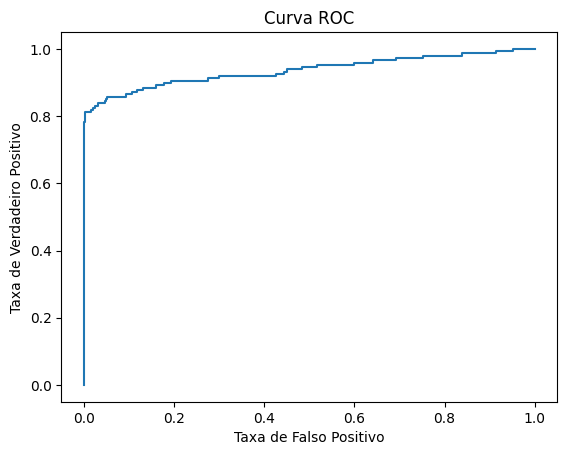

AUC: 0.935582786608638


In [35]:
from sklearn.metrics import roc_curve, roc_auc_score

y_probs = modelo.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("Curva ROC")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

O modelo apresenta uma taxa de acerto de aproximadamente 93.5%, ainda que seja boa, é preciso que essa taxa seja maior. 

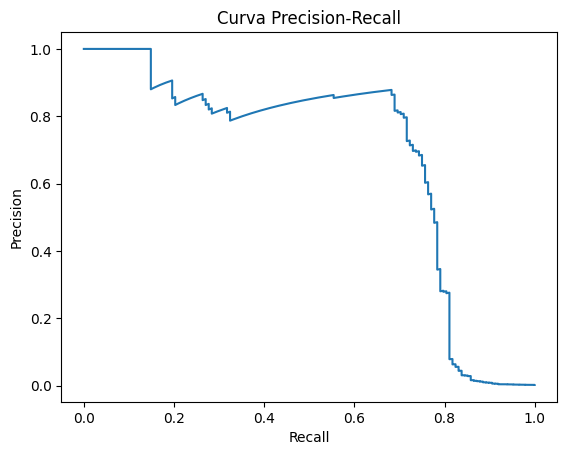

In [36]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

Quanto mais alta e próxima do canto superior direito a curva estiver, melhor é o modelo. O gráfico mostra o equilíbrio entre a precisão dos alertas (eixo vertical) e a capacidade de não deixar passar nenhuma falha/fraude (eixo horizontal).

<h2>Equilíbrio de Métricas</h2>
<p>O balanceamento é necessário ser feito porque muita das vezes uma métrica pode acabar destruindo a outra. Para isso, temos a métrica do F1-Score que é uma média harmônica da Precision e o Recall e fornece uma nota única de equilíbrio.</p>

In [37]:
#Undersampling

fraudes = df[df['Class'] == 1]
normais = df[df['Class'] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [38]:
#Oversampling

from imblearn.over_sampling import SMOTE

smote = SMOTE()  

x_res, y_res = smote.fit_resample(x, y)

<h2>Random Forest Classifier</h2>

<p>O Random Forest Classifier é um algoritmo de aprendizado de máquina supervisionado baseado em um conjunto de árvores de decisão. Em vez de utilizar apenas uma árvore para realizar a classificação, o modelo cria diversas árvores treinadas com diferentes amostras dos dados e combina suas previsões por meio de votação. Essa estratégia reduz o risco de overfitting, aumenta a precisão e torna o modelo mais robusto e confiável para tarefas de classificação.</p>

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=1,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.74      0.80      0.77       148

    accuracy                           1.00     85443
   macro avg       0.87      0.90      0.89     85443
weighted avg       1.00      1.00      1.00     85443



In [40]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

In [41]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.69      0.76       148

    accuracy                           1.00     85443
   macro avg       0.92      0.84      0.88     85443
weighted avg       1.00      1.00      1.00     85443



<h2>XGBoost</h2>

<p>O XGBoost (Extreme Gradient Boosting) é um algoritmo de aprendizado de máquina supervisionado baseado na técnica de gradient boosting. Seu funcionamento consiste em construir várias árvores de decisão de forma sequencial, em que cada nova árvore busca corrigir os erros cometidos pelas anteriores. Essa abordagem permite que o modelo alcance alta precisão e seja eficiente na resolução de problemas de classificação e regressão.</p>

In [42]:
from xgboost import XGBClassifier

xgb = XGBClassifier(

    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=10,
    random_state=42,
    eval_metric="logloss",
)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

In [43]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.81      0.80      0.80       148

    accuracy                           1.00     85443
   macro avg       0.90      0.90      0.90     85443
weighted avg       1.00      1.00      1.00     85443



<h2>Ajuste de hiperparâmetros</h2>

<p>Vamos testar várias combinações para melhorar o modelo</p>

In [44]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(x_train, y_train)

print("Melhor modelo: ", grid.best_params_)
print(grid.best_score_)

Melhor modelo:  {'max_depth': 5, 'n_estimators': 100}
0.014619883040935672


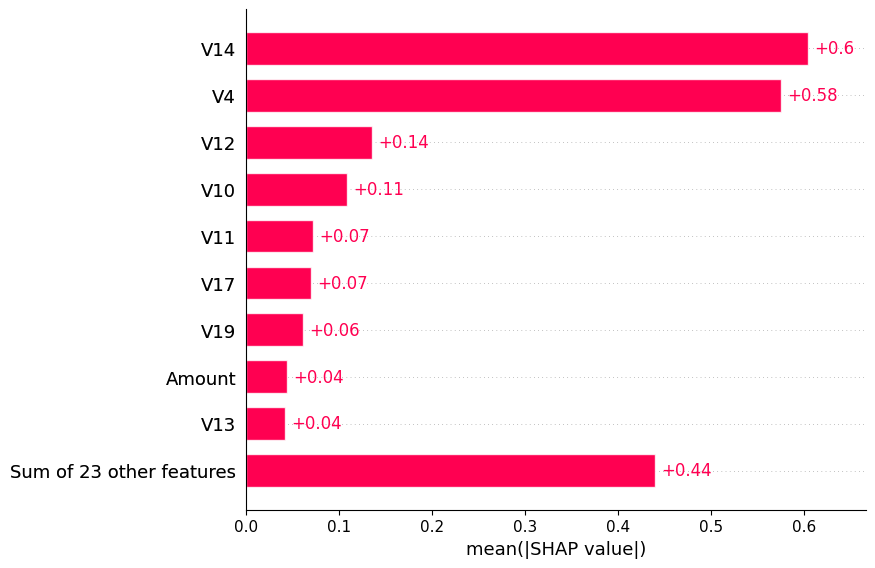

In [45]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(x_test[:100])

shap.plots.bar(shap_values)

Explicabilidade (SHAP) mostra como cada variável influencia a decisão do modelo.